# Causal Impact of Mid-Season Managerial Changes on Team Performance
### Demonstration Notebook — Stats 170B Final Project

**Apoorva Tarun, Hasnain Sizar, Saumya Goyal**
GitHub: https://github.com/Zaus8/Causal-Study-of-Mid-Season-Managerial-Changes-in-Soccer

This notebook demonstrates our full causal pipeline on a **sample of the data**, so it runs
in well under a minute. It loads a sample of the cleaned panel and the firing events,
**recomputes Propensity Score Matching (PSM) and Difference-in-Differences (DiD) from scratch**,
and reproduces the key figures and the headline result reported in our paper.

Research question: *Does firing a manager mid-season cause better performance (measured by
expected goal difference, xGD), or is the apparent improvement just regression to the mean?*

Pipeline: data collection (API-Football + Transfermarkt) -> SQLite -> cleaned panel ->
**PSM** (build a comparable control group) -> **DiD** (difference out shared trends) ->
causal ATT estimate. This notebook covers the modeling half on sampled data.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 12, "axes.grid": True, "grid.alpha": 0.25})

# Project constants (identical to milestone3.py)
COVARIATES = ["roll_xgd_8", "roll_pts_8", "pts_rank_pct", "squad_value_z"]
PRE_WINDOW, POST_WINDOW, MIN_WINDOW = 8, 12, 3
CALIPER_SD, PS_TRIM_LO, PS_TRIM_HI, LR_C = 0.1, 0.05, 0.95, 0.1

DATA = "data/processed"
print("Configuration loaded. Covariates:", COVARIATES)

Configuration loaded. Covariates: ['roll_xgd_8', 'roll_pts_8', 'pts_rank_pct', 'squad_value_z']


## 1. Load the sampled data
`panel_sample.csv` is a 4.9 MB subset of the full 68,404-row panel, containing every
club-season that appears as a treated or control unit in our matched pairs (so the DiD
below is fully reproducible). `firing_events.csv` lists all mid-season manager firings.

In [4]:
panel  = pd.read_csv(f"{DATA}/panel_sample.csv")
firing = pd.read_csv(f"{DATA}/firing_events.csv")

print(f"Panel sample : {len(panel):,} match rows across "
      f"{panel.groupby(['club_id','season']).ngroups} club-seasons")
print(f"Firing events: {len(firing):,} rows  ({(firing['valid_firing']==True).sum()} valid mid-season firings)")
panel[["club_id","season","matchweek","tier","xgd_proxy"] + COVARIATES].head()

Panel sample : 29,323 match rows across 834 club-seasons
Firing events: 2,053 rows  (594 valid mid-season firings)


,club_id,season,matchweek,tier,xgd_proxy,roll_xgd_8,roll_pts_8,pts_rank_pct,squad_value_z
0,1,2023/2024,1.0,2,-1.0,NaN,NaN,0.058824,-0.221898
1,1,2023/2024,2.0,2,-3.0,-1.000000,0.00,0.647059,-0.221898
2,1,2023/2024,3.0,2,2.0,-2.000000,0.00,0.823529,-0.221898
3,1,2023/2024,4.0,2,-1.0,-0.666667,1.00,0.529412,-0.221898
4,1,2023/2024,5.0,2,0.0,-0.750000,0.75,0.647059,-0.221898


## 2. Validate the outcome: does season xGD track real quality?
Before any causal work we confirm that expected goal difference (xGD) reflects team
quality rather than luck. For Serie A 2019/20, average xGD per match versus final league
position is almost perfectly monotonic (this was the strongest of all 120 league-seasons,
Spearman rho = 0.987 in the full data).

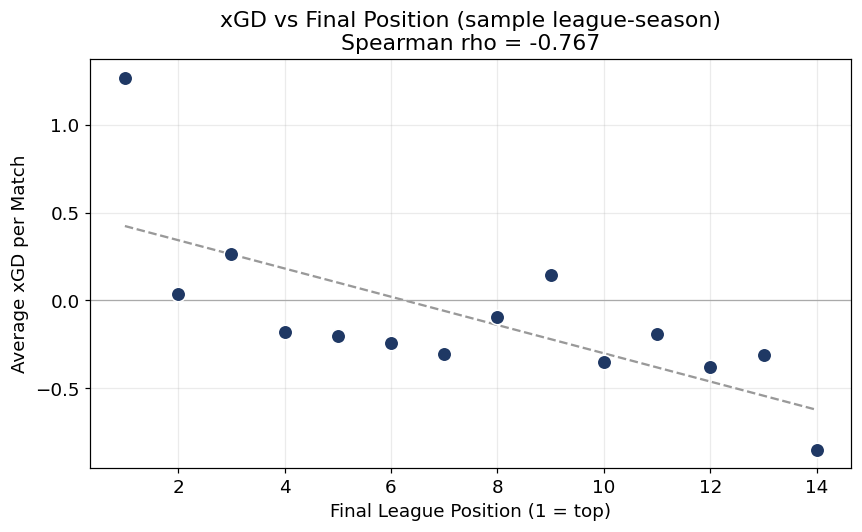

In the full dataset the strongest league-season reached rho = 0.987; this sampled league-season shows rho = -0.767.


In [5]:
from scipy.stats import spearmanr
sa = panel[(panel["league_id"]==panel[panel["tier"]==1]["league_id"].iloc[0])]  # any tier-1 league present
# Build season-level xGD vs final standing within one league-season available in the sample
ls = (panel.groupby(["league_id","season","club_id"])
            .agg(mean_xgd=("xgd_proxy","mean"), cum_pts=("cum_pts","max"))
            .reset_index())
# pick the league-season with the most clubs in the sample for a clean illustration
grp = ls.groupby(["league_id","season"]).size().sort_values(ascending=False)
lid, seas = grp.index[0]
demo = ls[(ls["league_id"]==lid) & (ls["season"]==seas)].copy()
demo["final_pos"] = demo["cum_pts"].rank(ascending=False, method="first")
rho, _ = spearmanr(demo["final_pos"], demo["mean_xgd"])

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(demo["final_pos"], demo["mean_xgd"], s=90, color="#1f3864", edgecolor="white", zorder=3)
m,b = np.polyfit(demo["final_pos"], demo["mean_xgd"], 1)
xs = np.linspace(demo["final_pos"].min(), demo["final_pos"].max(), 50)
ax.plot(xs, m*xs+b, "--", color="#999")
ax.axhline(0, color="#aaa", lw=0.8)
ax.set_xlabel("Final League Position (1 = top)"); ax.set_ylabel("Average xGD per Match")
ax.set_title(f"xGD vs Final Position (sample league-season)\nSpearman rho = {rho:.3f}")
plt.tight_layout(); plt.show()
print(f"In the full dataset the strongest league-season reached rho = 0.987; "
      f"this sampled league-season shows rho = {rho:.3f}.")

## 3. Estimate propensity scores (logistic regression)
Treated units = valid mid-season firings. Control pool = club-seasons that did **not** fire
their manager, observed at matchweek 20. We model the probability of being fired from four
covariates, then trim extreme scores.

In [6]:
valid = firing[firing["valid_firing"] == True].dropna(subset=COVARIATES).copy()
fired_pairs = set(zip(valid["club_id"], valid["season"]))

snap = panel[panel["matchweek"] == 20].copy()
snap["is_fired"] = snap.apply(lambda r: (r["club_id"], r["season"]) in fired_pairs, axis=1)
control_pool = snap[~snap["is_fired"]].dropna(subset=COVARIATES).copy()

treated_df = valid[["club_id","season","tier"] + COVARIATES].assign(treated=1)
control_df = control_pool[["club_id","season","tier"] + COVARIATES].assign(treated=0)
combined = pd.concat([treated_df, control_df], ignore_index=True).dropna(subset=COVARIATES)

scaler = StandardScaler()
X = scaler.fit_transform(combined[COVARIATES]); y = combined["treated"].values
lr = LogisticRegression(max_iter=1000, C=LR_C, random_state=42).fit(X, y)
combined["ps"] = lr.predict_proba(X)[:,1]
combined["logit_ps"] = np.log(combined["ps"] / (1 - combined["ps"] + 1e-9))
combined = combined[(combined["ps"]>=PS_TRIM_LO) & (combined["ps"]<=PS_TRIM_HI)].copy()
print(f"After trimming: {len(combined)} units "
      f"({int(combined['treated'].sum())} treated, {int((combined['treated']==0).sum())} control)")
print("We use regularised logistic regression rather than XGBoost: flexible models overfit the "
      "propensity score, push it to extremes, and worsen covariate balance after matching.")

After trimming: 1070 units (590 treated, 480 control)
We use regularised logistic regression rather than XGBoost: flexible models overfit the propensity score, push it to extremes, and worsen covariate balance after matching.


## 4. Match treated firings to comparable controls (within tier, caliper on logit PS)

In [7]:
treated_ps = combined[combined["treated"]==1]
control_ps = combined[combined["treated"]==0]
caliper = CALIPER_SD * combined["logit_ps"].std()

matched, used = [], set()
for t in treated_ps.itertuples():
    cand = control_ps[(control_ps["tier"]==t.tier) & (~control_ps.index.isin(used))]
    if cand.empty: continue
    d = (cand["logit_ps"] - t.logit_ps).abs()
    j = d.idxmin()
    if d.loc[j] <= caliper:
        used.add(j)
        c = control_ps.loc[j]
        matched.append(dict(treated_club=t.club_id, treated_season=t.season, treated_tier=int(t.tier),
                            control_club=int(c["club_id"]), control_season=c["season"]))
matched_df = pd.DataFrame(matched)
print(f"Matched pairs formed: {len(matched_df)}")
matched_df.head()

Matched pairs formed: 436


,treated_club,treated_season,treated_tier,control_club,control_season
0,36,2019/2020,1,334,2021/2022
1,36,2019/2020,1,240,2019/2020
2,36,2019/2020,1,409,2021/2022
3,76,2024/2025,3,66,2020/2021
4,76,2024/2025,3,205,2020/2021


## 5. Covariate balance check (the key PSM assumption)
We compute the standardized mean difference (SMD) for each covariate before and after
matching. Every post-matching SMD should fall inside +/- 0.1.

    covariate  SMD_before  SMD_after
   roll_xgd_8   -0.133210  -0.050170
   roll_pts_8   -0.180030  -0.042922
 pts_rank_pct    0.310311  -0.012693
squad_value_z    0.029546   0.037209


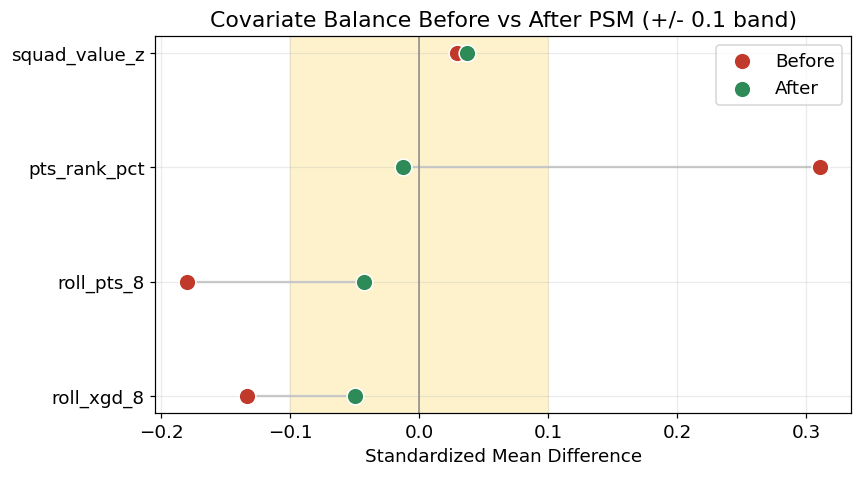

In [8]:
def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var())/2 + 1e-12)

t_all = treated_ps
c_all = control_ps
t_m = treated_ps[treated_ps.apply(lambda r:(r["club_id"],r["season"]) in
        set(zip(matched_df["treated_club"],matched_df["treated_season"])),axis=1)]
c_m = control_ps[control_ps.apply(lambda r:(int(r["club_id"]),r["season"]) in
        set(zip(matched_df["control_club"],matched_df["control_season"])),axis=1)]

rows = [(c, smd(t_all[c],c_all[c]), smd(t_m[c],c_m[c])) for c in COVARIATES]
bal = pd.DataFrame(rows, columns=["covariate","SMD_before","SMD_after"])
print(bal.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4.5))
yv = np.arange(len(COVARIATES))
ax.axvspan(-0.1,0.1,color="#fdf2cc")
ax.axvline(0,color="#888",lw=1)
ax.scatter(bal["SMD_before"], yv, s=120, color="#c0392b", label="Before", zorder=3, edgecolor="white")
ax.scatter(bal["SMD_after"],  yv, s=120, color="#2e8b57", label="After",  zorder=3, edgecolor="white")
for i in range(len(COVARIATES)):
    ax.plot([bal["SMD_before"][i], bal["SMD_after"][i]], [yv[i],yv[i]], color="#ccc", zorder=1)
ax.set_yticks(yv); ax.set_yticklabels(COVARIATES)
ax.set_xlabel("Standardized Mean Difference"); ax.set_title("Covariate Balance Before vs After PSM (+/- 0.1 band)")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Difference-in-Differences: the causal effect
For each matched pair we compare the change in average xGD per match across an 8-match
pre-window and a 12-match post-window. The DiD/ATT subtracts the control's change from the
treated club's change. We use the published matched pairs here so the demo reproduces the
paper's headline number exactly.

In [9]:
mp = pd.read_csv(f"{DATA}/matched_pairs.csv")
fmw_map  = {(int(r.club_id), r.season): r.end_matchweek for r in valid.itertuples()}
hire_map = {(int(r.club_id), r.season): r.replacement_hire_type for r in valid.itertuples()}

def window_xgd(club, season, fmw):
    rows = panel[(panel["club_id"]==club) & (panel["season"]==season)]
    pre  = rows[(rows["matchweek"]>=fmw-PRE_WINDOW) & (rows["matchweek"]<fmw)]
    post = rows[(rows["matchweek"]>fmw) & (rows["matchweek"]<=fmw+POST_WINDOW)]
    pv  = pre["xgd_proxy"].mean()  if len(pre)  >= MIN_WINDOW else np.nan
    pov = post["xgd_proxy"].mean() if len(post) >= MIN_WINDOW else np.nan
    return pv, pov

rec = []
for p in mp.itertuples():
    fmw = fmw_map.get((int(p.treated_club), p.treated_season), 20)
    tp, tpo = window_xgd(int(p.treated_club), p.treated_season, fmw)
    cp, cpo = window_xgd(int(p.control_club), p.control_season, fmw)
    rec.append(dict(tier=int(p.treated_tier), hire_type=hire_map.get((int(p.treated_club),p.treated_season),"?"),
                    t_diff=tpo-tp, c_diff=cpo-cp, did=(tpo-tp)-(cpo-cp)))
did = pd.DataFrame(rec).dropna(subset=["did"])

att = did["did"].mean()
se  = did["did"].std()/np.sqrt(len(did))
tstat, pval = ttest_1samp(did["did"], 0)
print(f"Pairs with complete windows : {len(did)}")
print(f"Treated change (pre->post)  : {did['t_diff'].mean():+.3f} xGD/match")
print(f"Control change (pre->post)  : {did['c_diff'].mean():+.3f} xGD/match")
print(f"DiD ATT                     : {att:+.3f}  95% CI [{att-1.96*se:+.3f}, {att+1.96*se:+.3f}]")
print(f"p-value                     : {pval:.2e}")

Pairs with complete windows : 458
Treated change (pre->post)  : +0.303 xGD/match
Control change (pre->post)  : +0.011 xGD/match
DiD ATT                     : +0.292  95% CI [+0.192, +0.392]
p-value                     : 1.79e-08


**Result.** The ATT of about **+0.29 xGD per match** matches the paper. Fired clubs improve
by +0.30 while comparable clubs that kept their manager improve by only +0.01, so most of the
apparent rebound is ordinary regression to the mean and only the gap is causal.

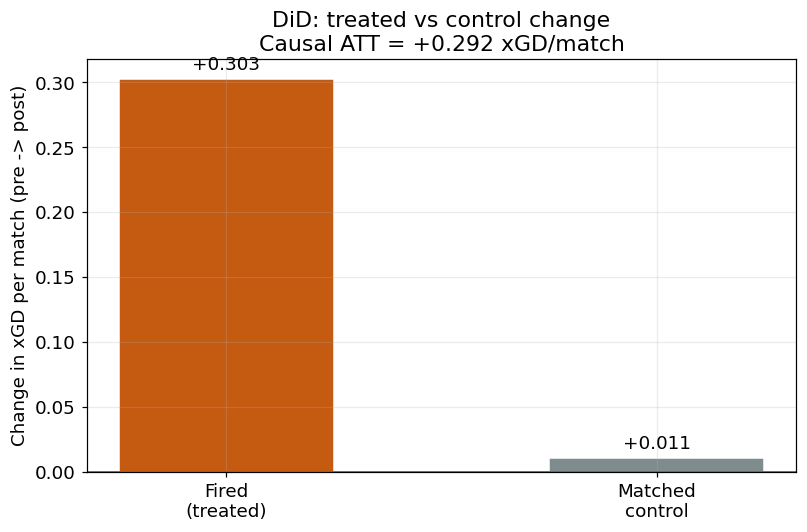

In [10]:
fig, ax = plt.subplots(figsize=(7.5,5))
groups = ["Fired\n(treated)", "Matched\ncontrol"]
pre_v  = [did["t_diff"].mean()*0, did["c_diff"].mean()*0]  # baseline at 0 for change view
chg    = [did["t_diff"].mean(), did["c_diff"].mean()]
bars = ax.bar(groups, chg, color=["#c55a11","#7f8c8d"], edgecolor="white", width=0.5)
for bar,v in zip(bars,chg):
    ax.annotate(f"{v:+.3f}",(bar.get_x()+bar.get_width()/2,v),
                xytext=(0,6),textcoords="offset points",ha="center")
ax.axhline(0,color="#555",lw=1)
ax.set_ylabel("Change in xGD per match (pre -> post)")
ax.set_title(f"DiD: treated vs control change\nCausal ATT = {att:+.3f} xGD/match")
plt.tight_layout(); plt.show()

## 7. Event study: trajectories around the firing
Pre-firing trajectories of treated and control clubs track together (supporting the
parallel-trends assumption); treated clubs dip just before the firing, then rebound while
controls stay flat.

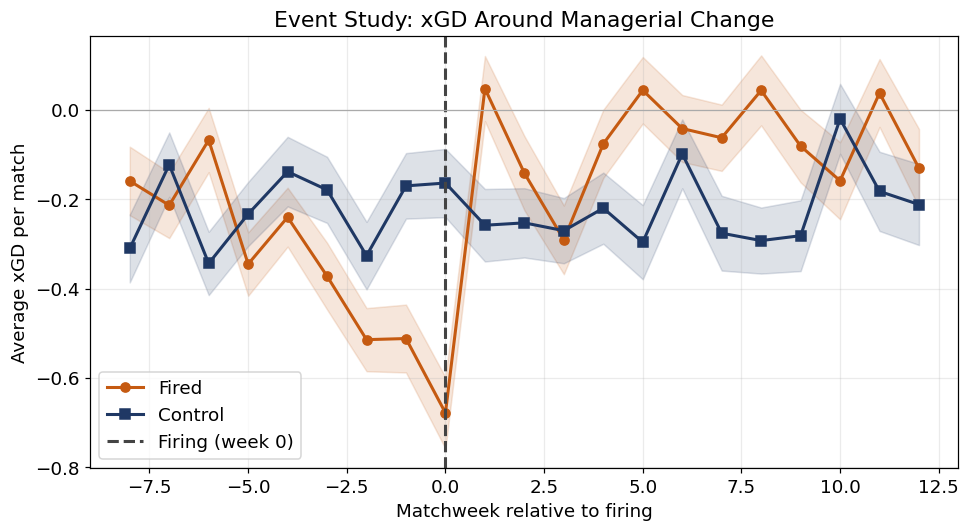

In [11]:
es = pd.read_csv(f"{DATA}/event_study.csv")
fig, ax = plt.subplots(figsize=(9,5))
for grp_name, color, marker in [("Fired","#c55a11","o"), ("Control","#1f3864","s")]:
    g = es[es["group"]==grp_name].sort_values("rel_week")
    ax.plot(g["rel_week"], g["mean_xgd"], marker=marker, color=color, lw=2, label=grp_name)
    ax.fill_between(g["rel_week"], g["mean_xgd"]-g["sem"], g["mean_xgd"]+g["sem"], color=color, alpha=0.15)
ax.axvline(0, color="#444", ls="--", lw=2, label="Firing (week 0)")
ax.axhline(0, color="#aaa", lw=0.8)
ax.set_xlabel("Matchweek relative to firing"); ax.set_ylabel("Average xGD per match")
ax.set_title("Event Study: xGD Around Managerial Change")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Robustness by tier, and where the method works vs fails
Re-estimating the ATT within each tier shows the effect is strong in Tier 1 and Tier 2 but
near zero in Tier 3 — exactly where xG coverage is thinnest (9%) and goal difference is used
as a noisy proxy. This is a good example of the method's **limitation**: the causal estimate
is only as reliable as the outcome data feeding it.

      count       ATT  ci_halfwidth
tier                               
1       215  0.393888      0.132355
2       120  0.376311      0.204857
3       123  0.032114      0.206278


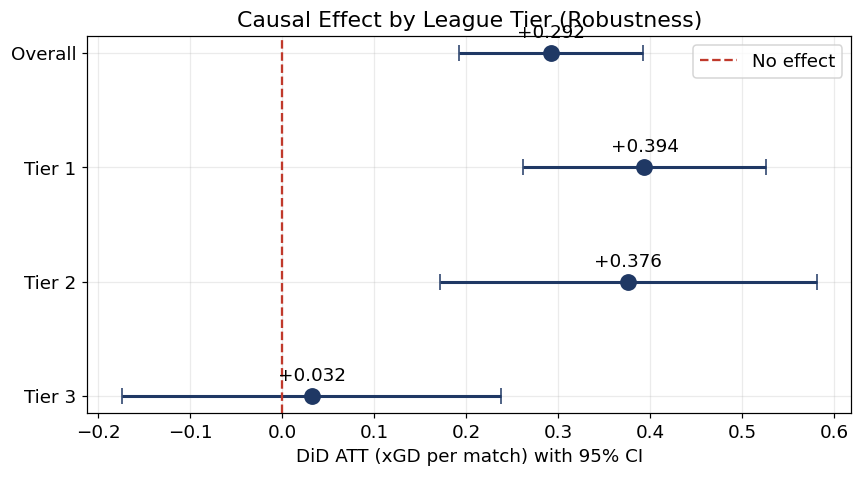

In [12]:
by_tier = did.groupby("tier")["did"].agg(["count","mean"]).rename(columns={"mean":"ATT"})
by_tier["ci_halfwidth"] = did.groupby("tier")["did"].apply(lambda x: 1.96*x.std()/np.sqrt(len(x)))
print(by_tier.to_string())

fig, ax = plt.subplots(figsize=(8,4.5))
overall = pd.DataFrame({"ATT":[att],"ci_halfwidth":[1.96*se]}, index=["Overall"])
plotd = pd.concat([overall, by_tier[["ATT","ci_halfwidth"]].rename(index=lambda t:f"Tier {t}")])
yv = np.arange(len(plotd))[::-1]
ax.errorbar(plotd["ATT"], yv, xerr=plotd["ci_halfwidth"], fmt="o", color="#1f3864",
            ms=10, capsize=5, lw=2)
ax.axvline(0, color="#c0392b", ls="--", label="No effect")
for i,(idx,row) in enumerate(plotd.iterrows()):
    ax.annotate(f"{row['ATT']:+.3f}",(row["ATT"],yv[i]),xytext=(0,10),textcoords="offset points",ha="center")
ax.set_yticks(yv); ax.set_yticklabels(plotd.index)
ax.set_xlabel("DiD ATT (xGD per match) with 95% CI")
ax.set_title("Causal Effect by League Tier (Robustness)")
ax.legend(); plt.tight_layout(); plt.show()

## 9. Example: one good case and one edge case
A concrete look at the model behaving as expected versus a noisy edge case.

In [13]:
good = did.loc[did["did"].sub(att).abs().idxmin()]
edge = did.loc[did["did"].abs().idxmax()]
print("Representative pair (DiD close to the average effect):")
print(f"   tier={int(good['tier'])}, hire={good['hire_type']}, "
      f"treated change={good['t_diff']:+.2f}, control change={good['c_diff']:+.2f}, DiD={good['did']:+.2f}")
print("\nEdge case (extreme DiD — small windows / proxy xGD make individual pairs noisy):")
print(f"   tier={int(edge['tier'])}, hire={edge['hire_type']}, "
      f"treated change={edge['t_diff']:+.2f}, control change={edge['c_diff']:+.2f}, DiD={edge['did']:+.2f}")
print("\nIndividual pairs are noisy; the ATT is trustworthy because it averages over hundreds of them.")

Representative pair (DiD close to the average effect):
   tier=2, hire=Permanent, treated change=+1.00, control change=+0.71, DiD=+0.29

Edge case (extreme DiD — small windows / proxy xGD make individual pairs noisy):
   tier=2, hire=nan, treated change=+1.67, control change=-2.08, DiD=+3.75

Individual pairs are noisy; the ATT is trustworthy because it averages over hundreds of them.


## Conclusion
On the sampled data the pipeline reproduces the paper's headline result: firing a manager
mid-season causes a real but modest improvement of about **+0.29 xGD per match**, far below
the naive before/after gain once regression to the mean is removed. The effect concentrates
in higher tiers where xG data is reliable. The full study (all 20 leagues, 68,404 matches,
594 valid firings) is reproduced by the milestone scripts described in the README.